# **Predict Customer churn**

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib
pd.set_option('display.max_columns', None)

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold

In [157]:
#train_ds = pd.read_csv(r"/kaggle/input/competitions/playground-series-s6e3/train.csv")
train_ds = pd.read_csv(r"Data/train.csv")
print(f"Training dataset shape: {train_ds.shape}")
train_ds.head()

Training dataset shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [158]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [159]:
train_ds.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#### Preprocessing

In [160]:
# check missing values
train_ds.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [161]:
# check duplicate values
train_ds.duplicated().sum()

np.int64(0)

#### Encoding

In [162]:
train_ds.head(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No


In [163]:
# check unique values in each column
cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

ohe_en_cols = []
label_en_cols = []
for col in cols:
    print(f"{col}: {len(train_ds[col].unique())}")
    if len(train_ds[col].unique()) == 2:
        ohe_en_cols.append(col)
    else:
        label_en_cols.append(col)

gender: 2
SeniorCitizen: 2
Partner: 2
Dependents: 2
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4
Churn: 2


In [164]:
# OneHotEncoding columns

ohe = OneHotEncoder(drop='first')
train_ds[ohe_en_cols] = ohe.fit_transform(train_ds[ohe_en_cols]).toarray()

In [165]:
# LabelEncoding columns
le = LabelEncoder()
for le_col in label_en_cols:
    train_ds[le_col] = le.fit_transform(train_ds[le_col])

#### Data Visualization

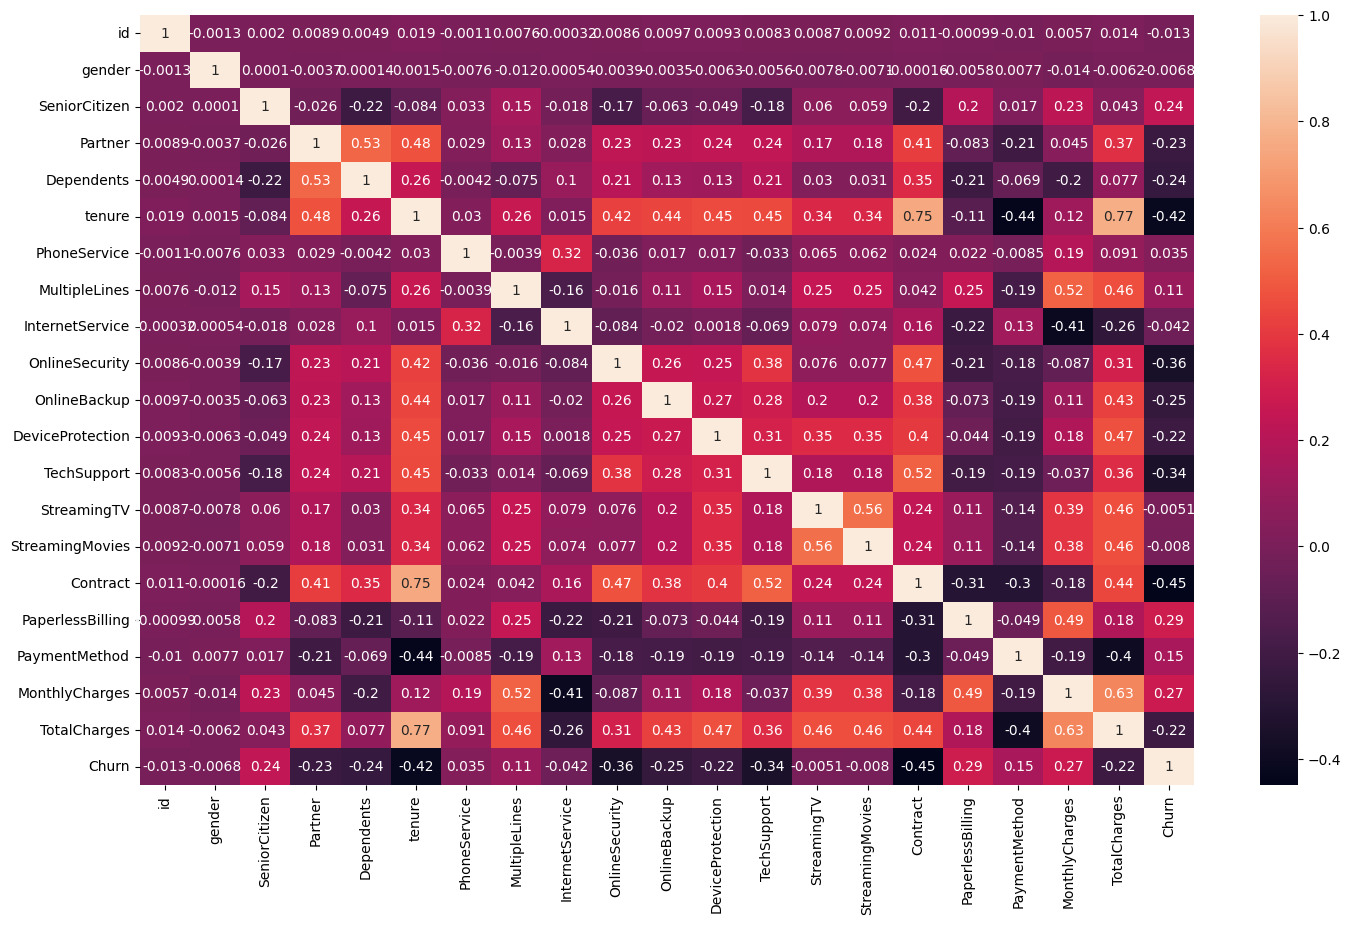

In [166]:
corr = train_ds.corr()

plt.figure(figsize=(17, 10))
sns.heatmap(corr, annot=True)
plt.show()

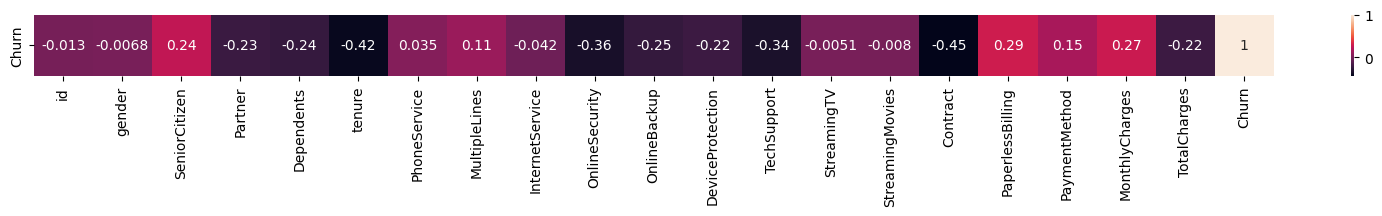

In [167]:
plt.figure(figsize=(20, 0.8))
sns.heatmap(corr.tail(1), annot=True)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_12416\938991326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_ds, palette='Set2')


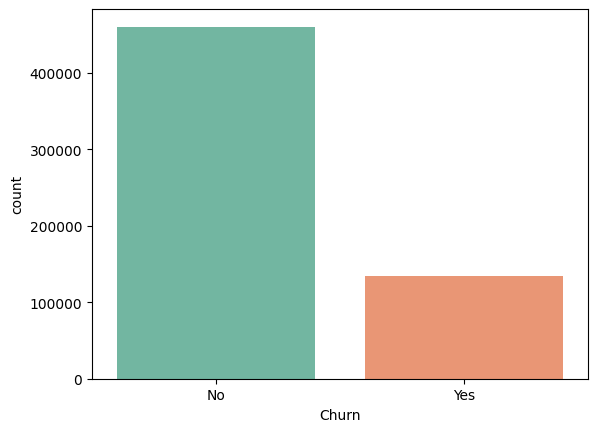

In [168]:
# counter plot
sns.countplot(x='Churn', data=train_ds, palette='Set2')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

#### Outlier Detection

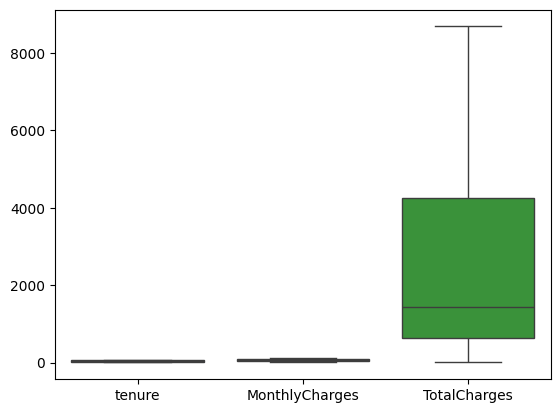

In [169]:
sns.boxplot(data=train_ds[['tenure', 'MonthlyCharges', 'TotalCharges']])
plt.show()

### Feature Engineering

In [171]:
train_ds['TotalSpendApprox'] =  train_ds['MonthlyCharges'] / train_ds['tenure'] 

In [172]:
train_ds.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalSpendApprox'],
      dtype='object')

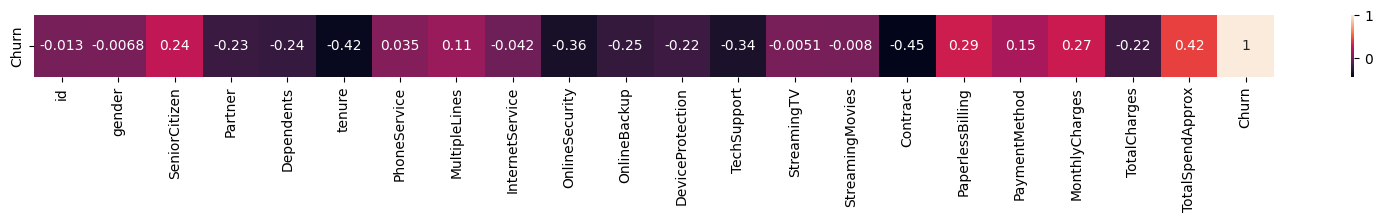

In [173]:
train_ds = train_ds[['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges','TotalSpendApprox', 'Churn' ]]

corr = train_ds.corr()
plt.figure(figsize=(20, 0.8))
sns.heatmap(corr.tail(1), annot=True)
plt.show()


#### Data Scaling

In [ ]:
x = train_ds.drop('Churn', axis=1)
y = train_ds['Churn']

In [ ]:
ss = StandardScaler()
x[['TotalCharges', 'TotalSpendApprox']] = ss.fit_transform(x[[ 'TotalCharges', 'TotalSpendApprox']])

In [ ]:
# Save Scaling model 
joblib.dump(ss, 'scaling_model.pkl')
print("Scaling model saved successfully.")

Scaling model saved successfully.


#### TrainTestSplit data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Feature Selection

In [ ]:
## This process highly time consuming
#fs = SequentialFeatureSelector(XGBClassifier(), n_features_to_select=10, direction='forward')
#fs.fit(x,y)

#### Cross Validation

In [ ]:
# cross_val_score(DecisionTreeClassifier(
#     max_depth=10,
#     min_samples_split=2,
#     min_samples_leaf=2
#     ),
#     x_train,
#     y_train,
#     cv=StratifiedKFold(n_splits=5)
#     )

#### Model Training 

#LogisticRegression

In [ ]:
# lr = LogisticRehgression()
# lr.fit(x_train, y_train)

In [ ]:
# print(f" Train_score: {lr.score(x_train, y_train)}\n Test_score: {lr.score(x_test, y_test)}")

#DTclassifier

In [ ]:
# dt = DecisionTreeClassifier(max_depth=10)
# dt.fit(x_train, y_train)

In [ ]:
# print(f" Train_score: {dt.score(x_train, y_train)}\n Test_score: {dt.score(x_test, y_test)}")

#Xgboost

In [ ]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print(f" Train_score: {xgb.score(x_train, y_train)}\n Test_score: {xgb.score(x_test, y_test)}")

 Train_score: 0.8648946576768941
 Test_score: 0.8608453453832496


#Lightgbm

In [ ]:
lgbm = LGBMClassifier()
lgbm.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 106913, number of negative: 368442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224912 -> initscore=-1.237268
[LightGBM] [Info] Start training from score -1.237268


LGBMClassifier()

In [ ]:
print(f" Train_score: {lgbm.score(x_train, y_train)}\n Test_score: {lgbm.score(x_test, y_test)}")

 Train_score: 0.8606325798613668
 Test_score: 0.8606097324952247


#Catboost

In [ ]:
ctb = CatBoostClassifier(verbose=0)
ctb.fit(x_train, y_train)

In [ ]:
print(f" Train_score: {ctb.score(x_train, y_train)}\n Test_score: {ctb.score(x_test, y_test)}")

 Train_score: 0.8677598847177372
 Test_score: 0.8607948569072442


#### Hyper Parameter tuning

In [ ]:
# randcv = RandomizedSearchCV(
#     estimator=DecisionTreeClassifier(),
#     param_distributions={
#         'max_depth': [5, 10, 15, 20, 25],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4]
#     },
#     n_iter=10,
#     cv=StratifiedKFold(n_splits=5),
#     random_state=42
# )

# randcv.fit(x_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=DecisionTreeClassifier(),
                   param_distributions={'max_depth': [5, 10, 15, 20, 25],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42)

In [ ]:
# randcv.best_params_

{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

In [ ]:
# dt = DecisionTreeClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=2)
# dt.fit(x, y)
# print(f" Train_score: {dt.score(x_train, y_train)}\n Test_score: {dt.score(x_test, y_test)}")

### Final Submission

In [ ]:
joblib.dump(lgbm, 'lgbm_model.pkl')
print("Successfully model saved")

Successfully model saved


In [ ]:
model = joblib.load("lgbm_model.pkl")
test_ds = pd.read_csv("Data/test.csv")

scaler = joblib.load("scaling_model.pkl")

In [ ]:
print(f"x_test_shape: {test_ds.shape}\nx_train_shape: {x_train.shape}")

x_test_shape: (254655, 20)
x_train_shape: (475355, 20)


In [ ]:
# check unique values in each column
cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

ohe_en_cols = []
label_en_cols = []
for col in cols:
    if len(train_ds[col].unique()) == 2:
        ohe_en_cols.append(col)
    else:
        label_en_cols.append(col)


# OneHotEncoding columns
ohe = OneHotEncoder(drop='first')
test_ds[ohe_en_cols] = ohe.fit_transform(test_ds[ohe_en_cols]).toarray()

# LabelEncoding columns
le = LabelEncoder()
for le_col in label_en_cols:
    test_ds[le_col] = le.fit_transform(test_ds[le_col])

 
# Scaling columns
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
test_ds[scale_cols] = scaler.transform(test_ds[scale_cols])

In [ ]:
test_ds.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,0.0,0.0,1.0,0.0,1.413410,1.0,2,1,2,2,2,2,2,2,2,1.0,2,1.599225,2.365049
1,594195,0.0,0.0,1.0,0.0,1.373509,1.0,0,2,1,1,1,1,1,1,2,0.0,0,-1.482782,-0.491894
2,594196,1.0,0.0,0.0,0.0,-0.980662,1.0,0,0,2,2,0,0,0,0,0,1.0,0,-0.332059,-0.790524


In [ ]:
## Prediction
churn = xgb.predict_proba(test_ds)[:, 1]
churn = churn.round(1)
churn = pd.DataFrame(churn, columns=['Churn'])

In [ ]:
submission = pd.concat([test_ds['id'], churn], axis=1)
submission.to_csv("xgb_submission.csv", index=False)

In [ ]:
submission

,id,Churn
0,594194,0.1
1,594195,0.0
2,594196,0.1
3,594197,0.0
4,594198,0.5
...,...,...
254650,848844,0.0
254651,848845,0.8
254652,848846,0.3
254653,848847,0.0


### Evaluation

In [ ]:
y_prd = lgbm.predict(x_test)
y_prd2 = xgb.predict(x_test)
y_prd3 = ctb.predict(x_test)

In [ ]:
# Confusion matrix
print(f"prd: {confusion_matrix(y_test, y_prd)}")
print()
print(f"prd_2: {confusion_matrix(y_test, y_prd2)}")
print()
print(f"prd_3: {confusion_matrix(y_test, y_prd3)}")

prd: [[85083  6852]
 [ 9615 17289]]

prd_2: [[85003  6932]
 [ 9543 17361]]

prd_3: [[85112  6823]
 [ 9605 17299]]


In [ ]:
roc_auc_score(y_test, y_test)

np.float64(1.0)